In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [3]:
raw_data, raw_labels = mnist["data"], mnist["target"]

In [4]:
print(mnist["DESCR"])

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

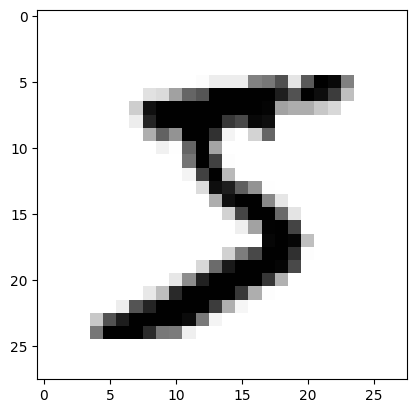

In [5]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
some_digit = raw_data[0]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap = mpl.cm.binary, interpolation="nearest")
plt.axis("on")
plt.grid(False)
plt.show()

In [6]:
raw_labels[11]

'5'

#### We need to convert the string type lables to numerical data type as almost any machine learning model tends to perform better in numerical data compared to string or object datatype

In [7]:
raw_labels = raw_labels.astype(np.uint8)

In [8]:
raw_labels[11]

np.uint8(5)

#### Dividing the data into train set and test set. For our dataset the data is already divided into train set and test set. The first 60000 data are train set rest 10000 dataset is test set  

In [9]:
X_train, X_test, y_train, y_test = raw_data[:60000], raw_data[60000:], raw_labels[:60000], raw_labels[60000:]


#### Firstly we create a binary classifier which identifies if a digit is 5 or not before jumping to the actual model

In [10]:
y_train_5 : bool = []
y_test_5 : bool = []
for i in range(len(y_train)):
    if y_train[i] == 5:
        y_train_5.append(True) 
    else:
        y_train_5.append(False)

In [11]:
for i in range(len(y_test)):
    if y_test[i] == 5:
        y_test_5.append(True)
    else:
        y_test_5.append(False)

In [12]:
y_train_5_book = (y_train == 5)
y_test_5_book = (y_test == 5)
print(type(y_train_5))
print(type(y_test_5_book))
print(type(y_train_5_book))
print(type(y_test_5))

<class 'list'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'list'>


In [13]:
import joblib
from sklearn.linear_model import SGDClassifier
try:
    sgd_clf = joblib.load("sgd_model_predict_5.pkl")
    print("Model imported from saved models")
except Exception as e:
    sgd_clf = SGDClassifier(random_state=42)
    sgd_clf.fit(X_train, y_train_5_book)
    joblib.dump(sgd_clf, "sgd_model_predict_5.pkl")

Model imported from saved models


d:\Code Playground\Python\AI_ML\classificationDigits\.venv\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SGDClassifier from version 1.5.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [14]:
a_number = X_train[:15]
print(type(a_number))
sgd_clf.predict(a_number)

<class 'numpy.ndarray'>


array([ True, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False])

In [15]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

for train_index, test_index in skfolds.split(X_train, y_train_5_book):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5_book[train_index]
    X_test_folds = X_train[test_index]
    y_test_folds = y_train_5_book[test_index]
    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_folds)
    n_correct = sum(y_pred == y_test_folds)
    print(n_correct/len(y_pred))

0.9669
0.91625
0.96785


In [16]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5_book, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

#### Accuracy is not always the best measure for a classification model. Precision and recall and f1 score is considered to be more appropriate measure to measure the performance of a classification model.

In [17]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5_book, cv=3)

#### A confusion matrix of a binary classifier has 4 columns true negative, false positive, false negative and ture positive. Confusion matrix gives a good measure for classification models.

In [18]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5_book, y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

#### precision is tp/(tp + tn) and recall is tp/(tp + fn)
##### precision is the measure of how correct the model is and recall is the measure of how many wrong predictions the model is making. 
##### when you are building such a model where you cannot accept any wrong being classified as right you choose a model which has high precision
##### but when it is impotant for you to identify all the correct ones even if your model is sometimes terming wrong as right then you choose a model which has high recall

In [19]:
from sklearn.metrics import precision_score, recall_score
precision = precision_score(y_train_5_book, y_train_pred)
recall = recall_score(y_train_5_book, y_train_pred)
print(f"Precision: {precision}\nRecall: {recall}")

Precision: 0.8370879772350012
Recall: 0.6511713705958311


#### f1 score is the harmonic mean of precision score and recall score

In [20]:
from sklearn.metrics import f1_score
f1 = f1_score(y_train_5_book, y_train_pred)
print(f"The f1 score is: {f1}")

The f1 score is: 0.7325171197343847


#### decision function gives the threshold which helps the model to predict what value the digit is

In [21]:
decision_scores = sgd_clf.decision_function(X_train[:15])
for i, j in zip(decision_scores, y_train_5_book[:15]):
    print(f"{i}: {j}")

2164.2203023926586: True
-5897.373593538878: False
-13489.148057785078: False
-4623.845159432227: False
-6873.052484528889: False
-3908.2757629071402: False
-4851.942239699033: False
-4988.524077546987: False
-2226.7813286640758: False
-4081.3369283115107: False
-5711.4778968723085: False
4742.528131575118: True
-10322.619700870204: False
-5028.508042401304: False
-2774.489337011428: False


In [22]:
decision_scores = cross_val_predict(sgd_clf, X_train, y_train_5_book, method="decision_function", cv=3)
y_scores = decision_scores.copy()

#### decision function can be used to calculate the precision_recall curve

In [23]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5_book, y_scores)

In [24]:
thresholds.shape

(60000,)

In [25]:
print(f"The dimentions of \nprecision is: {precisions.shape}\nrecalls is: {recalls.shape}\nthreshold is:{thresholds.shape}")

The dimentions of 
precision is: (60001,)
recalls is: (60001,)
threshold is:(60000,)


#### drawing the recall vs precision curve to know the correct balance between the recall and precision

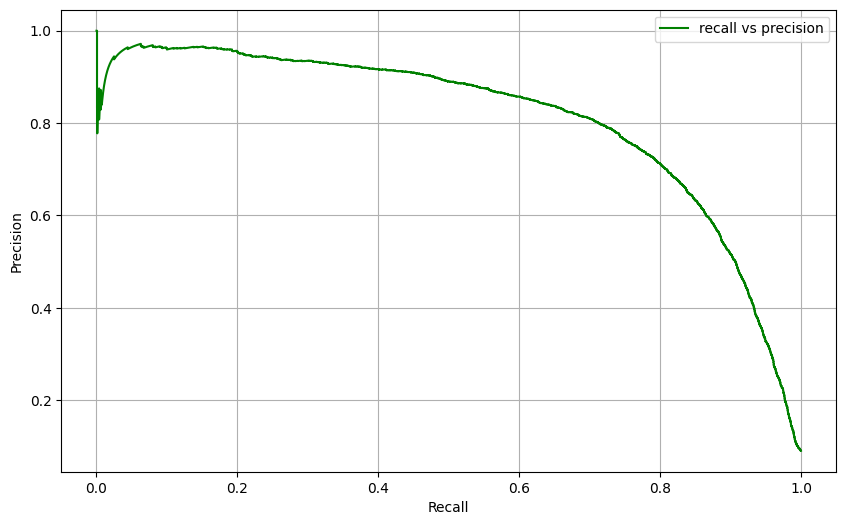

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(recalls[:recalls.shape[0]-1], precisions[:precisions.shape[0]-1], "g-", label="recall vs precision",)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()

#### Plotting recall and precision against threshold to find the tradeoff suitable for our model

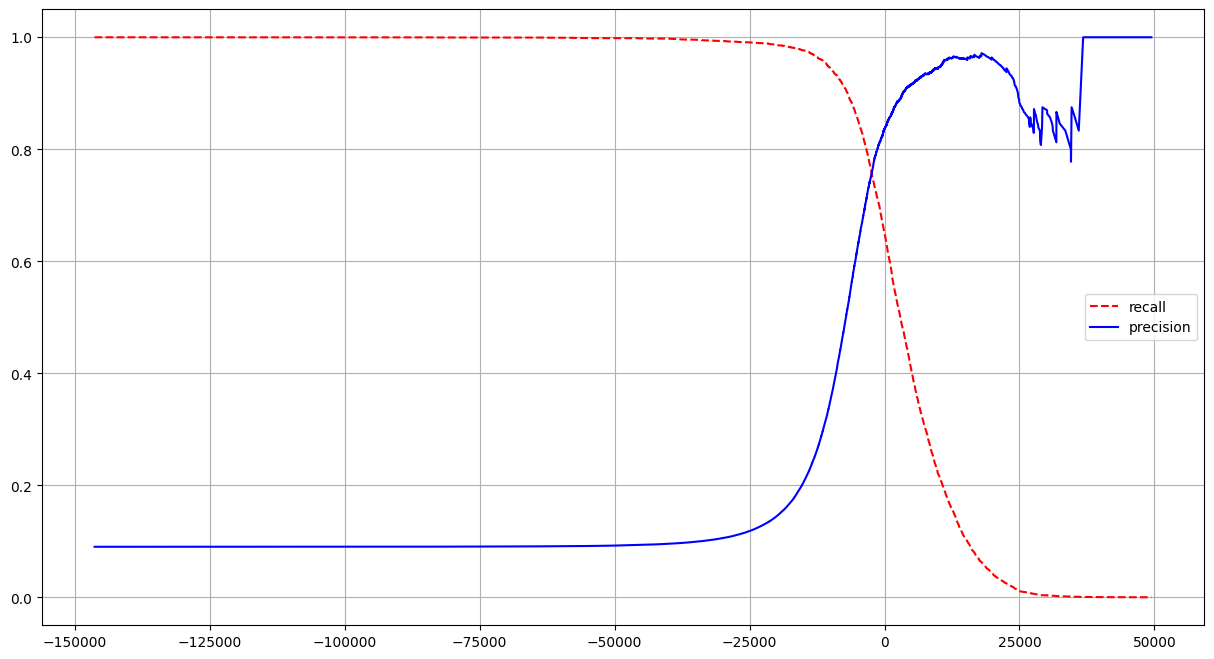

In [27]:
plt.figure(figsize=(15, 8))
plt.plot(thresholds, recalls[:-1], "r--", label="recall")
plt.plot(thresholds, precisions[:-1], "b", label="precision")
plt.grid(True)
plt.legend(loc=7)
plt.show()

In [28]:
threshold_90_precision = thresholds[np.argmax(precisions>=0.90)]
threshold_90_precision

np.float64(3370.0194991439557)

In [29]:
threshold_90_recall = thresholds[np.argmin(recalls>=0.90)]
threshold_90_recall

np.float64(-6861.032537940254)

In [30]:
y_train_pred_precision_90 = (y_scores >= threshold_90_precision)
newPrecision = precision_score(y_train_5_book, y_train_pred_precision_90)
newRecall = recall_score(y_train_5_book, y_train_pred_precision_90)
print(f"The new precision is {newPrecision}\nThe new recall is {newRecall}")

The new precision is 0.9000345901072293
The new recall is 0.4799852425751706


In [31]:
def setPrecision(prec_val, thresholds, precisions, scores, label) -> None:
    thresholdPrecision = thresholds[np.argmax(precisions >= prec_val)]
    print(f"For {prec_val} precision:\nThe new threshold is {thresholdPrecision}")
    y_train_new_precision = (scores >= thresholdPrecision)
    newPrec = precision_score(y_train_5_book, y_train_new_precision)
    newRec = recall_score(y_train_5_book, y_train_new_precision)
    print(f"The new precision is {newPrec}\nThe new recall is {newRec}")

In [32]:
setPrecision(0.90, thresholds, precisions, y_scores, y_train_5_book)

For 0.9 precision:
The new threshold is 3370.0194991439557
The new precision is 0.9000345901072293
The new recall is 0.4799852425751706


In [33]:
setPrecision(0.75, thresholds, precisions, y_scores, y_train_5_book)

For 0.75 precision:
The new threshold is -2551.6670906292175
The new precision is 0.75
The new recall is 0.7659103486441616


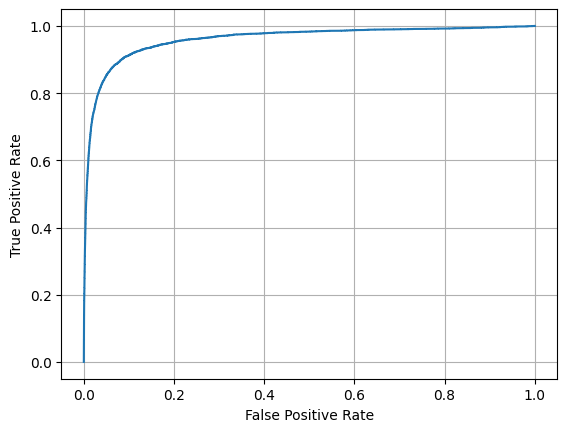

In [34]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_5_book, y_scores)
plt.plot(fpr, tpr)
plt.grid(True)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [35]:
from sklearn.metrics import roc_auc_score
roc_auc_scores = roc_auc_score(y_train_5_book, y_scores)
print(f"The roc area under curve score is: {roc_auc_scores}")

The roc area under curve score is: 0.9604938554008616


In [36]:
from sklearn.ensemble import RandomForestClassifier
rfc_classifier = RandomForestClassifier(random_state = 42)
cross_val_score(rfc_classifier, X_train, y_train_5_book, cv=3, scoring="accuracy")

array([0.98885, 0.9863 , 0.98635])

In [37]:
forest_d_scores = cross_val_predict(rfc_classifier, X_train, y_train_5_book, cv=3, method="predict_proba")

In [38]:
forest_d_scores.shape

(60000, 2)

In [39]:
roc_auc_rfc_scores = roc_auc_score(y_train_5_book, forest_d_scores[:, 1])
print(f"The roc score for random forest is: {roc_auc_rfc_scores}")

The roc score for random forest is: 0.9983436731328145


In [40]:
forest_pred_scores = cross_val_predict(rfc_classifier, X_train, y_train_5_book, cv=3)
confusion_matrix(y_train_5_book, forest_pred_scores)

array([[54534,    45],
       [  725,  4696]])

In [41]:
precision_score(y_train_5_book, forest_pred_scores)

0.9905083315756169

In [42]:
recall_score(y_train_5_book, forest_pred_scores)

0.8662608374838591

In [43]:
precision_forest, recall_forest, threshold_forest = precision_recall_curve(y_train_5_book, forest_d_scores[:,1])

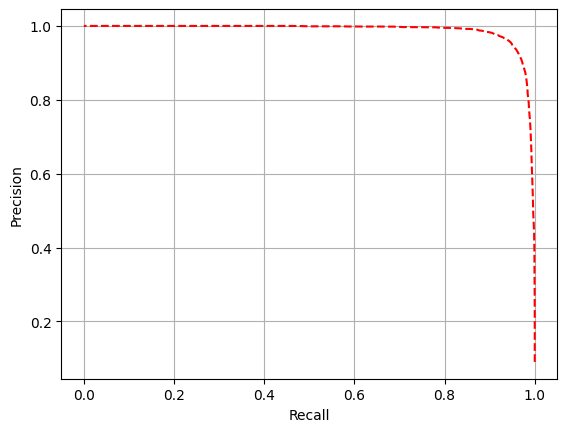

In [44]:
plt.plot(recall_forest, precision_forest, "r--", label="recall vs precision")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()

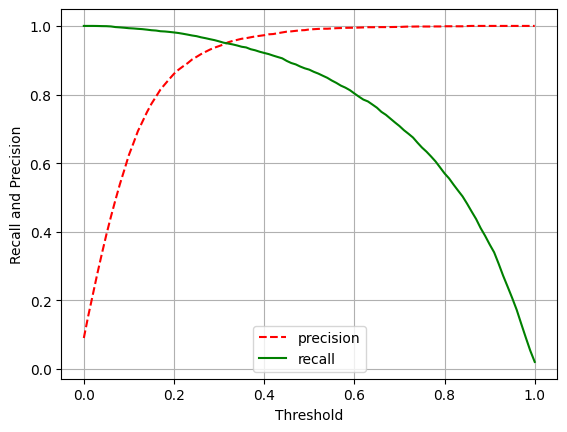

In [45]:
plt.plot(threshold_forest, precision_forest[:-1], "r--", label="precision")
plt.plot(threshold_forest, recall_forest[:-1], "g", label="recall")
plt.xlabel("Threshold")
plt.ylabel("Recall and Precision")
plt.legend(loc=8)
plt.grid(True)
plt.show()

In [46]:
setPrecision(0.95, threshold_forest, precision_forest, forest_d_scores[:, 1], y_train_5_book)

For 0.95 precision:
The new threshold is 0.32
The new precision is 0.9522310683206814
The new recall is 0.9487179487179487


In [47]:
fpr_forest, tpr_forest, threshold_rfc = roc_curve(y_train_5_book, forest_d_scores[:, 1])

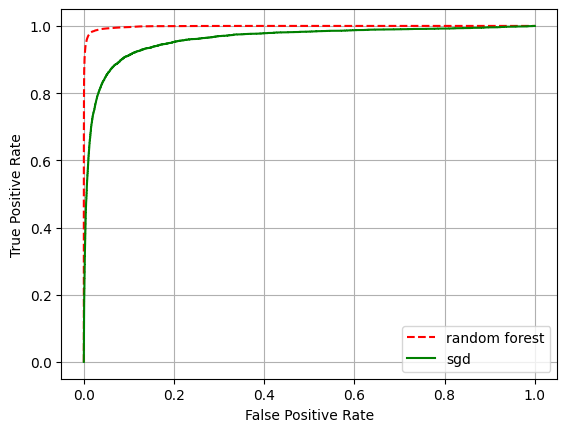

In [48]:
plt.plot(fpr_forest, tpr_forest, "r--", label="random forest")
plt.plot(fpr, tpr, "g", label="sgd",)
plt.grid(True)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

In [49]:
from sklearn.model_selection import GridSearchCV
try:
    best_sgd_model = joblib.load("best_sgd_model_binary.pkl")
    print("Saved model found\nImported from saved model")
except Exception as e:
    param_grid = [
        {
            "loss": ['hinge', 'squared_hinge'],
            "max_iter": [200, 500, 1000, 2000, 3000],
            "n_jobs": [-1],
            "learning_rate": ['optimal'],
        }
    ]
    sgd_for_grid = SGDClassifier()
    grid_search = GridSearchCV(sgd_for_grid, param_grid, 
                               scoring="accuracy", 
                               n_jobs=-1, cv=5, 
                               return_train_score=True)
    grid_search.fit(X_train, y_train_5_book)
    best_sgd_model = grid_search.best_estimator_
    joblib.dump(best_sgd_model, "best_sgd_model_binary.pkl")

Saved model found
Imported from saved model


In [50]:
best_sgd_pred = best_sgd_model.predict(X_train)
precision_score_best_sgd = precision_score(y_train_5_book, best_sgd_pred)
recall_score_best_sgd = recall_score(y_train_5_book, best_sgd_pred)
print(f"The precision is: {precision_score_best_sgd}\nThe recall score: {recall_score_best_sgd}")

The precision is: 0.9403327596098681
The recall score: 0.6046854823833241


In [51]:
best_sgd_decision_scores = best_sgd_model.decision_function(X_train)
roc_score_best_sgd = roc_auc_score(y_train_5_book, best_sgd_decision_scores)
print(f"The roc auc score is {roc_score_best_sgd}")

The roc auc score is 0.9729704720805338


In [52]:
try:
    sgd_full_data = joblib.load("ovr_sgd_clf.pkl")
    print("Saved model found\nImported from saved model")
except Exception as e:
    sgd_full_data = SGDClassifier()
    sgd_full_data.fit(X_train, y_train)
    joblib.dump(sgd_full_data, "ovr_sgd_clf.pkl")

Saved model found
Imported from saved model


In [53]:
sgd_full_data.predict([raw_data[11], some_digit])

array([5, 3], dtype=uint8)

In [54]:
sgd_full_data.decision_function([raw_data[11]])

array([[-24979.72160379, -10472.2614079 ,  -4057.98638728,
        -11284.4487607 ,  -7330.4273682 ,   3276.71960605,
        -16752.3031591 , -11097.09936133,   -503.07122549,
        -10474.04110308]])

In [55]:
from sklearn.multiclass import OneVsOneClassifier
try:
    ovo_sgd_clf = joblib.load("ovo_sgd_clf.pkl")
    print("Saved model found\nImported from saved model")
except Exception as e:
    ovo_sgd_clf = OneVsOneClassifier(SGDClassifier(random_state=42, n_jobs=-1))
    ovo_sgd_clf.fit(X_train, y_train)
    joblib.dump(ovo_sgd_clf, "ovo_sgd_clf.pkl")

Saved model found
Imported from saved model


In [56]:
ovo_sgd_clf.predict([some_digit, raw_data[11]])

array([5, 5], dtype=uint8)

In [57]:
try:
    random_full_forest = joblib.load("random_full_dataset.pkl")
    print("Saved model found\nImported from saved model")
except Exception as e:
    random_full_forest = RandomForestClassifier(random_state=42, n_jobs=-1)
    random_full_forest.fit(X_train, y_train)
    joblib.dump(random_full_forest, "random_full_dataset.pkl")

Saved model found
Imported from saved model


In [58]:
random_full_forest.predict([some_digit, raw_data[11]])

array([5, 5], dtype=uint8)

In [59]:
random_full_forest.predict_proba([some_digit, raw_data[11]])

array([[0.  , 0.  , 0.01, 0.08, 0.  , 0.9 , 0.  , 0.  , 0.  , 0.01],
       [0.01, 0.05, 0.02, 0.  , 0.  , 0.9 , 0.  , 0.  , 0.01, 0.01]])

In [60]:
ovo_sgd_cross_scores = cross_val_score(ovo_sgd_clf, X_train, y_train, scoring="accuracy", n_jobs=-1)

In [61]:
ovo_sgd_cross_scores

array([0.92025   , 0.91641667, 0.91575   , 0.89841667, 0.91225   ])

In [62]:
ovr_sgd_cross_val_scores = cross_val_score(sgd_full_data, X_train, y_train, scoring="accuracy", n_jobs=-1)

In [63]:
ovr_sgd_cross_val_scores

array([0.88616667, 0.87008333, 0.86483333, 0.87375   , 0.88266667])

In [64]:
random_forest_full_cross_val_scores = cross_val_score(random_full_forest, X_train, y_train, scoring="accuracy", n_jobs=-1)

In [65]:
random_forest_full_cross_val_scores

array([0.96808333, 0.96566667, 0.96541667, 0.962     , 0.97108333])

In [66]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
random_forest_full_scaled_cross_val_scores = cross_val_score(random_full_forest, X_train_scaled, y_train, scoring="accuracy", n_jobs=-1)
print(random_forest_full_scaled_cross_val_scores)

[0.96816667 0.96575    0.96591667 0.962      0.971     ]


In [67]:
y_train_pred_r_forest_cross = cross_val_predict(random_full_forest, X_train_scaled, y_train)
conf_mx = confusion_matrix(y_train, y_train_pred_r_forest_cross)
conf_mx

array([[5846,    2,    7,    2,    4,    6,   19,    1,   32,    4],
       [   1, 6637,   32,   16,   14,    4,    7,   15,   10,    6],
       [  24,   11, 5756,   30,   31,    2,   19,   39,   39,    7],
       [   8,    6,   82, 5819,    1,   65,    8,   53,   61,   28],
       [  12,   12,   11,    0, 5671,    0,   20,   11,   17,   88],
       [  25,    7,   11,   58,    9, 5210,   41,    5,   32,   23],
       [  25,   11,    1,    0,    8,   32, 5818,    0,   23,    0],
       [   4,   22,   64,    6,   42,    1,    1, 6044,   13,   68],
       [  11,   28,   35,   51,   26,   49,   25,    6, 5554,   66],
       [  24,   11,   16,   79,   69,   18,    4,   51,   38, 5639]])

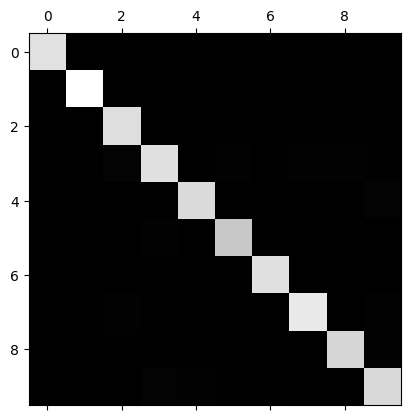

In [68]:
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()

#### Find the row sum to see the rate of good detection

In [69]:
row_sum = conf_mx.sum(axis=1, keepdims=True)
norm_conf_mx = conf_mx / row_sum

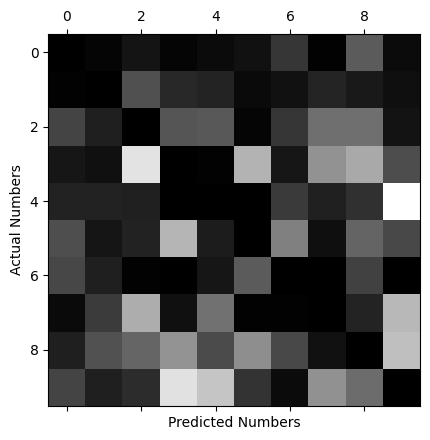

In [70]:
np.fill_diagonal(norm_conf_mx, 0)
plt.matshow(norm_conf_mx, cmap=plt.cm.gray)
plt.xlabel("Predicted Numbers")
plt.ylabel("Actual Numbers")
plt.show()

#### Let's train a multiclass classification system which identifies if a digit is even or odd

In [71]:
from sklearn.neighbors import KNeighborsClassifier
y_train_even = (y_train % 2 == 0)
y_train_odd = (y_train % 2 != 0)
y_even_odd = np.c_[y_train_even, y_train_odd]
try:
    knn_clf = joblib.load("knn_even_odd.pkl")
    print("Imported from saved models")
except Exception as e:
    knn_clf = KNeighborsClassifier(n_jobs=-1, n_neighbors=10)
    knn_clf.fit(X_train, y_even_odd)
    joblib.dump(knn_clf, "knn_even_odd.pkl")

Imported from saved models


In [72]:
random_full_forest.predict([some_digit, raw_data[20]])

array([5, 4], dtype=uint8)

In [73]:
knn_clf.predict([some_digit, raw_data[20]])

array([[False,  True],
       [ True, False]])

#### Evaluating the multiclass model based on f1 score

In [74]:
knn_cross_val_predict = cross_val_predict(knn_clf, X_train, y_even_odd)
f1_multiclass_cross = f1_score(y_even_odd, knn_cross_val_predict, average="macro")
print(f"{f1_multiclass_cross} is the f1 score for multiclass model.")

0.9792989977679984 is the f1 score for multiclass model.


In [75]:
f1_multiclass_cross_weighted = f1_score(y_even_odd, knn_cross_val_predict, average="weighted")
print(f"{f1_multiclass_cross_weighted} is the f1 score for multiclass model.(average set to weighted)")

0.979333825253079 is the f1 score for multiclass model.(average set to weighted)


In [76]:
knn_predict = knn_clf.predict(X_train)
f1_multiclass = f1_score(y_even_odd, knn_predict, average="macro")
print(f"{f1_multiclass} is the f1 score for multiclass model(without cross val).")

0.9853803196663053 is the f1 score for multiclass model(without cross val).


In [77]:
f1_multiclass_weighted = f1_score(y_even_odd, knn_predict, average="weighted")
print(f"{f1_multiclass_weighted} is the f1 score for multiclass model.(average set to weighted)")

0.9854026471568955 is the f1 score for multiclass model.(average set to weighted)


### Multiclass Classification

#### clearing up images with noise in them with the help of multiclass classification 
+ new train set - we will add external noise to the train dataset
+ new train label - the old train set which is the set of clear image
+ new test set - we will add noise to the old test set
+ new test label - the old test set.\
__This has no connection with the prediction of numbers__

In [78]:

noise = np.random.randint(0, 100, X_train.shape)
X_train_mod = X_train + noise
noise = np.random.randint(0, 100, X_test.shape)
X_test_mod = X_test + noise

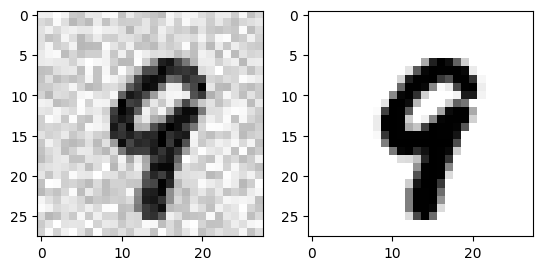

In [79]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
some_digit = X_train_mod[6969]
some_digit_image = some_digit.reshape(28, 28)
plt.subplot(1, 2, 1)
plt.imshow(some_digit_image, cmap = mpl.cm.binary, interpolation="nearest")
plt.axis("on")
plt.grid(False)
some_digit = X_train[6969]
some_digit_image = some_digit.reshape(28, 28)
plt.subplot(1, 2, 2)
plt.imshow(some_digit_image, cmap = mpl.cm.binary, interpolation="nearest")
plt.axis("on")
plt.grid(False)
plt.show()

In [80]:
print(y_train[6969])

9


In [81]:
try:
    knn_multiclass=joblib.load("knn_multiclass.pkl")
except Exception as e:
    knn_multiclass = KNeighborsClassifier(n_neighbors=10, n_jobs=-1)
    knn_multiclass.fit(X_train_mod, X_train)
    joblib.dump(knn_multiclass, "knn_multiclass.pkl")


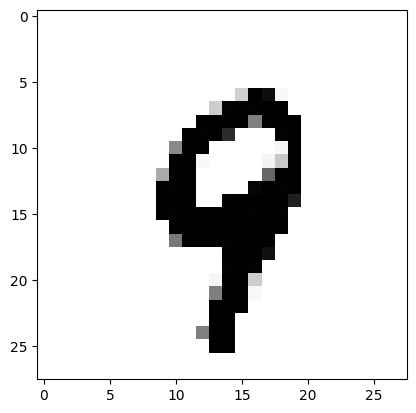

In [82]:
pred_num = knn_multiclass.predict([X_train_mod[6969]])
some_digit = pred_num
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap = mpl.cm.binary, interpolation="nearest")
plt.axis("on")
plt.grid(False)
plt.show()

#### image cleaning without using classification algorithms

In [83]:
trail_clean = some_digit_image.copy()
for i in range (28):
    for j in range (28):
        if(trail_clean[i][j] < 180):
            trail_clean[i][j] = 0
        else:
            trail_clean[i][j] = 255

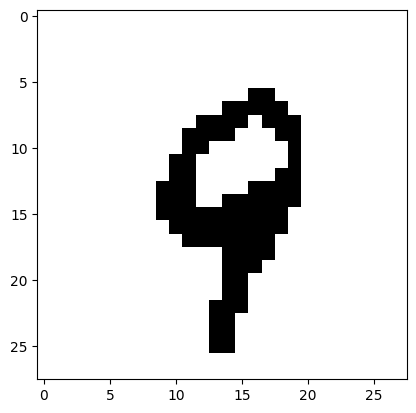

In [84]:
plt.imshow(trail_clean, cmap = mpl.cm.binary, interpolation="nearest")
plt.axis("on")
plt.grid(False)

#### Testing the random forest model on built on the full dataset on various scores

In [96]:
def judge_scores(model, data, labels):      
    random_x_train_pred = model.predict(data)
    p_score = precision_score(labels, random_x_train_pred, average="weighted")
    r_score = recall_score(labels, random_x_train_pred, average="weighted")
    f_score = f1_score(labels, random_x_train_pred, average="weighted")
    print(f"The precision score is : {p_score}\nThe recall score is: {r_score}\nThe f1 score is: {f_score}\n")

    random_x_train_pred = cross_val_predict(model, data, labels, method="predict")
    p_score = precision_score(labels, random_x_train_pred, average="weighted")
    r_score = recall_score(labels, random_x_train_pred, average="weighted")
    f_score = f1_score(labels, random_x_train_pred, average="weighted")
    print(f"The precision score is : {p_score}\nThe recall score is: {r_score}\nThe f1 score is: {f_score}")





In [ ]:
judge_scores(random_full_forest, X_train, y_train)

The precision score is : 1.0
The recall score is: 1.0
The f1 score is: 1.0

The precision score is : 0.9664253796396532
The recall score is: 0.96645
The f1 score is: 0.9664247196315459


#### Calculating the scores for the test set

In [ ]:
judge_scores(random_full_forest, X_test, y_test)

The precision score is : 0.970495753186874
The recall score is: 0.9705
The f1 score is: 0.9704722695987773

The precision score is : 0.9466470668021917
The recall score is: 0.9467
The f1 score is: 0.9465894841016514


In [94]:
try:
    best_random_full = joblib.load("best_random_full.pkl")
    print("Exported from saved models")
except Exception as e:
    param_grid = {
        "n_estimators": [750, 1000],
        "max_depth": [None,], 
        "min_samples_split": [2, 100], 
        "random_state":[42], 
        "n_jobs":[-1],
    }
    random_full_clf = RandomForestClassifier()
    grid_search = GridSearchCV(random_full_clf, param_grid, 
                               scoring="accuracy", 
                               n_jobs=-1, cv=5, 
                               return_train_score=True)
    grid_search.fit(X_train, y_train)
    best_random_full = grid_search.best_estimator_
    joblib.dump(best_random_full, "best_random_full.pkl")
    

In [92]:
grid_search.best_params_

{'max_depth': None,
 'min_samples_split': 2,
 'n_estimators': 750,
 'n_jobs': -1,
 'random_state': 42}

In [97]:
judge_scores(best_random_full, X_train, y_train)

The precision score is : 1.0
The recall score is: 1.0
The f1 score is: 1.0

The precision score is : 0.9688930283786341
The recall score is: 0.9689
The f1 score is: 0.9688851849099264
